# Cyber Trend Forecasting Transformer Pipeline

**Vignette Description:**
This notebook acts as the Pipeline Dashboard for the project. It handles the end-to-end workflow:
1.  **Setup:** Automatically detects if running on Google Colab or the NATO Local Server.
2.  **Training:** Executes `Train_Graph.py` to optimise the PDFormer model.
3.  **Evaluation:** Runs `Evaluate_Graph.py` to generate metrics and predictions.
4.  **Visualisation:** Runs `Visualise_Results.py` and displays the Gap Analysis inline.

## Universal Setup

This cell handles the setup logic: mounting Google Drive if on Colab, or using relative paths if on the GPU server

In [1]:
import os
import sys

# --- CONFIGURATION ---
# If on Colab, ensure you have set the Secret 'project_path' to your Project Root
# e.g., /content/drive/MyDrive/NATO_Project_Root

try:
    # 1. CHECK ENVIRONMENT: Try to import Colab-specific modules
    from google.colab import drive, userdata
    IS_COLAB = True
    print("--- Detected Environment: GOOGLE COLAB ---")
except ImportError:
    IS_COLAB = False
    print("--- Detected Environment: LOCAL SERVER (NATO/BBK) ---")

# 2. PATH SETUP
if IS_COLAB:
    # --- COLAB SETUP ---
    try:
        drive.mount('/content/drive')

        # Get the PARENT ROOT from Secrets
        PROJECT_ROOT = userdata.get('cyber_treat_path')
        if not PROJECT_ROOT:
            raise ValueError("Secret 'project_path' is missing.")

    except Exception as e:
        print(f"CRITICAL COLAB SETUP ERROR: {e}")
        # Stop execution if we can't find the files
        raise e
else:
    # --- LOCAL SETUP ---
    # We assume this notebook is in 'Notebooks/', so Root is one level up
    # os.getcwd() returns /.../Project_Root/Notebooks
    PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))

# 3. CONFIGURE WORKING DIRECTORY
# We need to run scripts from inside 'Transformer_Pipeline'
PIPELINE_DIR = os.path.join(PROJECT_ROOT, 'Transformer_Pipeline')

if not os.path.exists(PIPELINE_DIR):
    raise FileNotFoundError(f"Could not find pipeline folder at: {PIPELINE_DIR}")

# Change CWD to the pipeline folder so scripts can find config/data
os.chdir(PIPELINE_DIR)
print(f"SUCCESS: Working Directory set to: {os.getcwd()}")

# 4. ADD PROJECT ROOT TO SYS.PATH
# This allows us to import 'Notebooks.colab_utils' if needed
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)
    print(f"Added Project Root to sys.path: {PROJECT_ROOT}")

# 5. INSTALL DEPENDENCIES (COLAB ONLY)
if IS_COLAB:
    print("\n--- Installing Dependencies (Colab Only) ---")
    # We import the helper script from the sibling folder
    try:
        from Notebooks import Colab_Utils
        Colab_Utils.setup_environment(PIPELINE_DIR)
    except ImportError:
        print("WARNING: Could not import Notebooks.colab_utils. Skipping auto-install.")

--- Detected Environment: GOOGLE COLAB ---
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
SUCCESS: Working Directory set to: /content/drive/MyDrive/Research/NATO/code/Cyber-trend-forecasting/Transformer_Pipeline
Added Project Root to sys.path: /content/drive/MyDrive/Research/NATO/code/Cyber-trend-forecasting

--- Installing Dependencies (Colab Only) ---
--- Setting up Colab Environment ---

--- Checking Dependencies---
Target Directory: /content/drive/MyDrive/Research/NATO/code/Cyber-trend-forecasting/Transformer_Pipeline
torch is already installed.
torchvision is already installed.
tensorboard is already installed.
protobuf is already installed.
numpy is already installed.
pandas is already installed.
scipy is already installed.
networkx is already installed.
scikit-learn is already installed.
statsmodels is already installed.
hyperopt is already installed.
ray is already installed.
fastdtw is already in

## Optional: Re-Generate Graph Data

Run this cell if you want to rebuild the graph topology (Adjacency Matrices, Laplacian, etc.) from the raw CSV data. If you have already processed the data, you can skip this step.

In [ ]:
# Runs the preprocessing script to generate graph artifacts
# We use !python to run this as a clean subprocess

# We are currently in the 'Transformer_Pipeline' directory.
# The script will resolve paths automatically.

!python Preprocessing/Cyber_Trend_to_Graph.py --pdformer

--- Running Pre-processing (Module Mode) ---
Working Directory set to: /content/drive/MyDrive/Research/NATO/code/Cyber-trend-forecasting

 SUCCESS: Artifacts created at /content/drive/MyDrive/Research/NATO/code/Cyber-trend-forecasting/Processed_Data/graph/train.npz
You may now DELETE this cell and run the Training cell.


### New

In [ ]:
!python Preprocessing/Cyber_Trend_to_Graph.py --pdformer

--- Configuration ---
Source Data: /content/drive/MyDrive/Research/NATO/code/Cyber-trend-forecasting/Data_Preparation/Cyber_Trend_Forecasting_All.csv
Output Dir:  /content/drive/MyDrive/Research/NATO/code/Cyber-trend-forecasting/Processed_Data/Graph
Window Size: 10 months
Forecast Horizon: 36 months
Splits: Train=43%, Val=30%, Test=27%
DEBUG: Attempting to load file from: /content/drive/MyDrive/Research/NATO/code/Cyber-trend-forecasting/Data_Preparation/Cyber_Trend_Forecasting_All.csv
Loading raw data...
Parsing dates with format '%b-%y'...
Data loaded and sorted successfully.
 - Time Range: 2011-07-01 to 2025-01-01
 - Total Months: 163
 - DataFrame Shape: (163, 1231)

--- Applying Double Exponential Smoothing (alpha=0.1, beta=0.1) ---
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels

## Step 1: Train Graph Model (PDFormer)

We now execute the training script.
* **Input:** `Cyber_Trend_Graph_Config.py` (Hyperparameters)
* **Output:** `best_model_graph.pth` (Saved weights)

We provide 2 options for training, uncomment the commends accordingly:

`%run Train_Graph.py` (Interactive): Runs the script inside this notebook's memory. This allows you to inspect variables (like model or optimiser) after execution.

`!python Train_Graph.py` (Recommended for stability): Runs the script in a separate process. This ensures a "clean slate" execution, exactly as if you were running it on a server terminal.

*Note: If running on T4 GPU, should take 15-25 minutes.*

In [ ]:
print("--- Step 1: Training PDFormer Graph Model ---")
# Option A: Interactive (keeps variables in memory)
# We use %run to execute the script in a fresh namespace.
# This runs the script as if it were in the terminal, showing live progress bars.
# This is cleaner for demo purposes than importing the main function.
%run Train_Graph.py --batch_size 2

# Option B: Clean Subprocess (Recommended for reproducibility)
# !python Train_Graph.py

--- Step 1: Training PDFormer Graph Model ---
Loaded configuration for model: PDFormer
Using device: cuda

--- 3. Setting up DataLoaders ---
Initialising dataset for split: train from /content/drive/MyDrive/Research/NATO/code/Cyber-trend-forecasting/Processed_Data/Graph
Loading windowed data from /content/drive/MyDrive/Research/NATO/code/Cyber-trend-forecasting/Processed_Data/Graph/train.npz...
Loaded 25 samples for train.
Initialising dataset for split: val from /content/drive/MyDrive/Research/NATO/code/Cyber-trend-forecasting/Processed_Data/Graph
Loading windowed data from /content/drive/MyDrive/Research/NATO/code/Cyber-trend-forecasting/Processed_Data/Graph/val.npz...
Loaded 3 samples for val.
DataLoaders created successfully.

--- 4. Initialising Model ---
Loading static features from /content/drive/MyDrive/Research/NATO/code/Cyber-trend-forecasting/Processed_Data/Graph...
Calculating missing Laplacian Matrix (lap_mx) from Adjacency...


/content/drive/MyDrive/Research/NATO/code/Cyber-trend-forecasting/Transformer_Pipeline/Models/PDFormer_Wrapper.py:85: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.tensor(lap_np, dtype=torch.float32)


 - Moved adj_mx to cuda (Shape: (1231, 1231))
 - Moved dtw_matrix to cuda (Shape: (1231, 1231))
 - Moved sh_mx to cuda (Shape: (1231, 1231))
 - Moved sd_mx to cuda (Shape: (1231, 1231))
 - Moved pattern_keys to cuda (Shape: (16, 10, 1))
 - Moved lap_mx to cuda (Shape: (1231, 1231))
Auto-configured Model: Nodes=1231, Input Dim=1
Wrapper: Forced config num_nodes to 1231
Wrapper: Registered 'lap_mx' buffer successfully.
PDFormer engine initialised.

[Wrapper PATCH] Found mismatch in layer 'enc_embed_layer.spatial_embedding.embedding_lap_pos_enc'
 - Current In-Features: 8
 - Needed In-Features:  1231
 -> REPLACING LAYER...
 -> Successfully patched 'enc_embed_layer.spatial_embedding.embedding_lap_pos_enc'!
Model initialised. Total trainable parameters: 226061

--- 5. Setting up Loss and Optimiser ---

--- 6. Starting Training ---
Epoch 1/100 | Time: 4.2s | Train Loss: 0.1643 | Val Loss: 1.0350 | RSE: 1.1031 | 💾 Saved New Best Model (Loss: 1.0350)
Epoch 2/100 | Time: 3.5s | Train Loss: 0.117

## Step 2: Evaluation & Metrics

This step loads the best model saved above and runs it against the Test Set.
* It calculates **RSE, RAE, and MAE** across horizons (3, 6, 12, 24 months).
* It saves the raw predictions to `.npy` files for visualisation.
* It exports the **Column Names** metadata.

In [ ]:
print("--- Step 2: Evaluating Model on Test Set ---")
%run Evaluate_Graph.py

--- Step 2: Evaluating Model on Test Set ---


--- Loading Test Dataset ---
Initialising dataset for split: test from /content/drive/MyDrive/Research/NATO/code/Cyber-trend-forecasting/Processed_Data/Graph
Loading windowed data from /content/drive/MyDrive/Research/NATO/code/Cyber-trend-forecasting/Processed_Data/Graph/test.npz...
Loaded 10 samples for test.
Loading static features from /content/drive/MyDrive/Research/NATO/code/Cyber-trend-forecasting/Processed_Data/Graph...
Calculating missing Laplacian Matrix (lap_mx) from Adjacency...
--- Loading Model ---
Looking for weights at: /content/drive/MyDrive/Research/NATO/code/Cyber-trend-forecasting/Transformer_Pipeline/Checkpoints/best_model_graph.pth
Successfully loaded weights from /content/drive/MyDrive/Research/NATO/code/Cyber-trend-forecasting/Transformer_Pipeline/Checkpoints/best_model_graph.pth
--- Running Inference ---
DEBUG: Raw Prediction Shape: (10, 36, 1231, 1)
DEBUG: Squeezed 4D output to 3D.
Raw Output Shape: (10, 36, 1231)
--- Inverse Scaling Data ---
Loaded scaler from

## Step 3: Visualisation

Finally, we generate the paper-ready plots.
* **Forecast vs Actual:** Checks model accuracy on a specific node.
* **Gap Analysis:** Visualises the "Risk Gap" between **DDoS-ALL** (Threat) and **IDS/IPS Solutions** (Mitigation).

--- Step 3: Generating Visualisations ---
--- Starting Visualisation ---
Loading Graph Structure from: /content/drive/MyDrive/Research/NATO/code/Cyber-trend-forecasting/B-MTGNN/data/graph.csv

--- Generating Gap Analysis ---
Saved Table Image & LaTeX to: /content/drive/MyDrive/Research/NATO/code/Cyber-trend-forecasting/Transformer_Pipeline/Results/Strictly_Widening_Gaps.png

--- Strictly Widening Gaps (Top 5) ---
             Threat                                           PAT  2023  2024  2025             Trend
        Malware-ALL                  Solution_SANDBOXING_Mentions 0.738 0.829 1.169 Strictly Widening
        Malware-ALL          Solution_DARKNET MONITORING_Mentions 0.649 0.738 0.978 Strictly Widening
   Mentions-Dropper                  Solution_SANDBOXING_Mentions 0.516 0.631 0.850 Strictly Widening
Targeted Attack-ALL Solution_DYNAMIC RESOURCE MANAGEMENT_Mentions 0.422 0.501 0.644 Strictly Widening
        Malware-ALL    Solution_APPLICATION WHITELISTING_Mentions 0.272 0

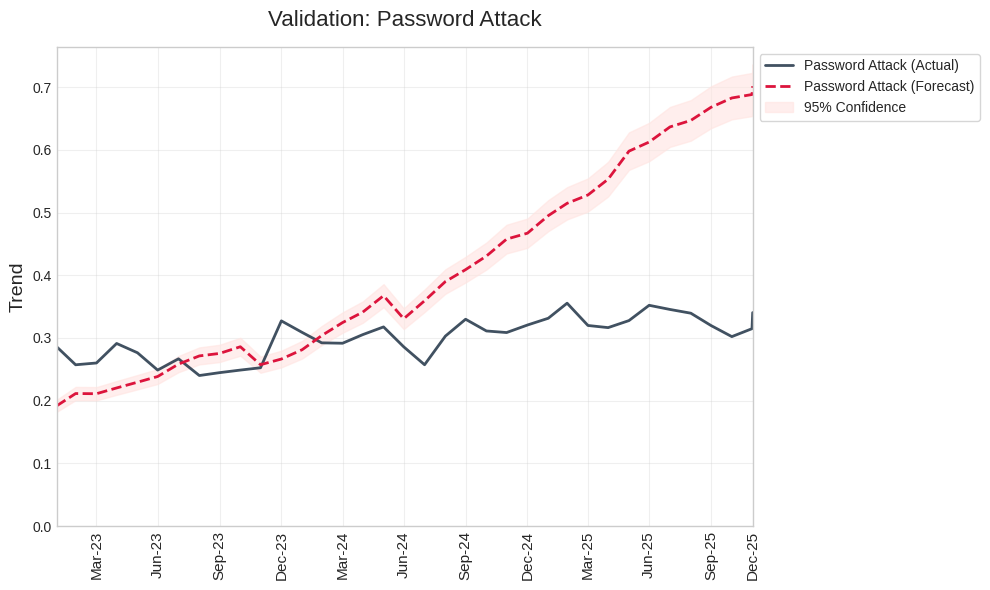

Displaying Plot: NLP/LLM


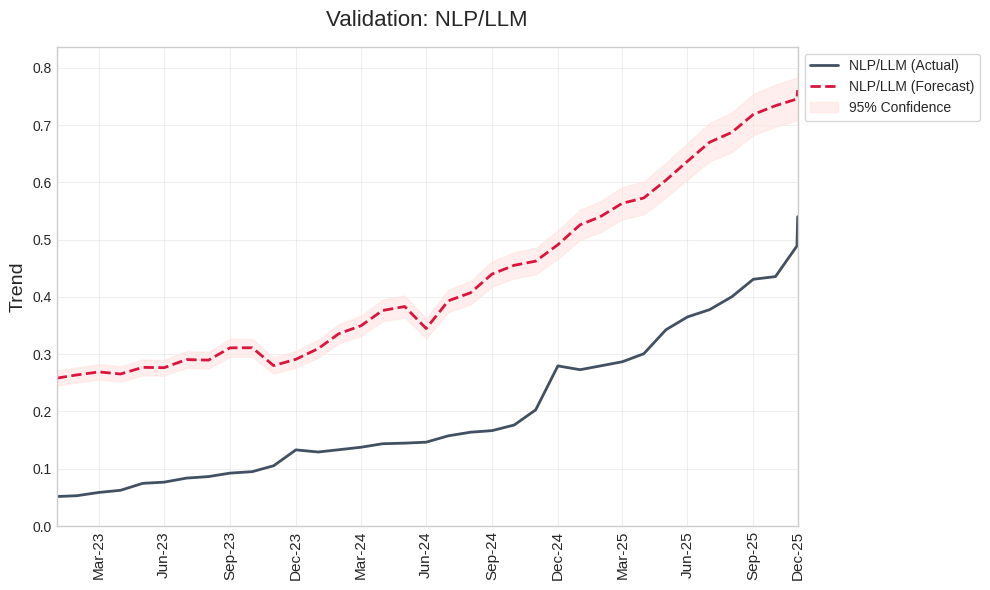

Displaying Plot: Data Backups


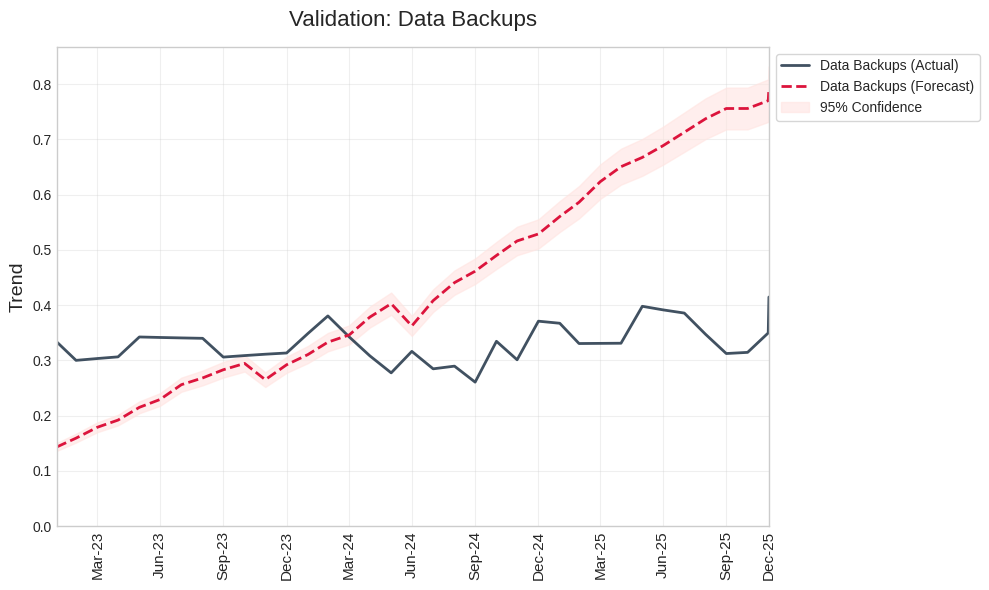

All plots and tables saved to: /content/drive/MyDrive/Research/NATO/code/Cyber-trend-forecasting/Transformer_Pipeline/Results/plots_paper_style

--- GAP ANALYSIS: Threat vs Mitigation ---


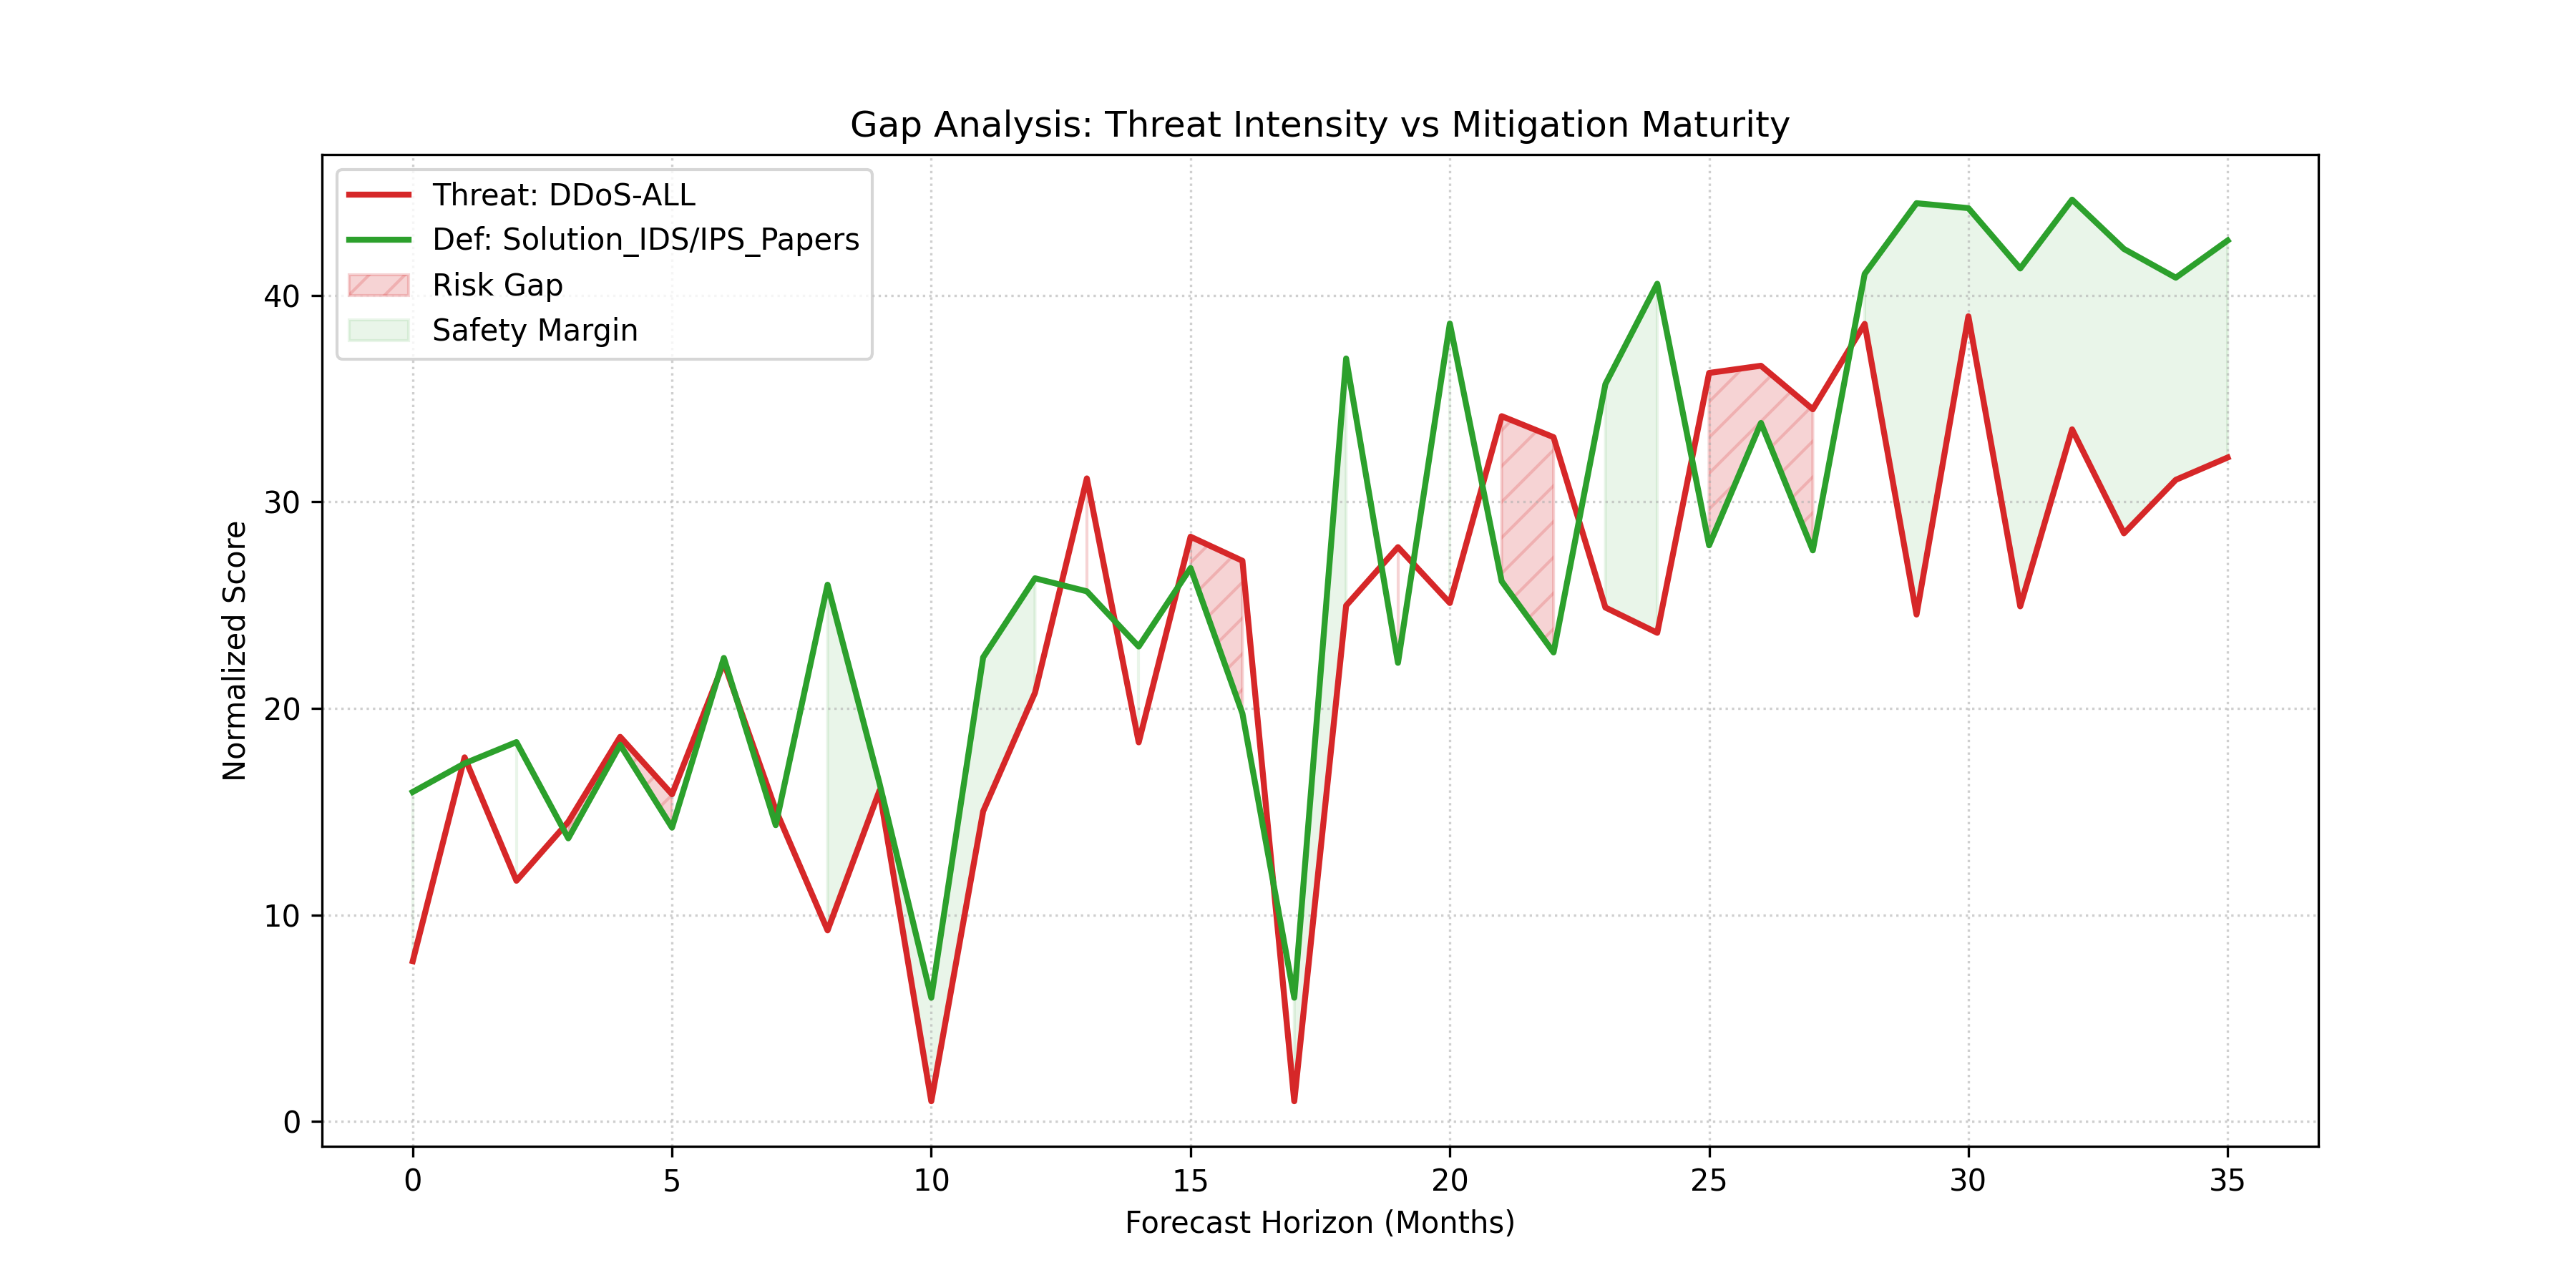


--- FORECAST ACCURACY: Ground Truth vs Prediction ---


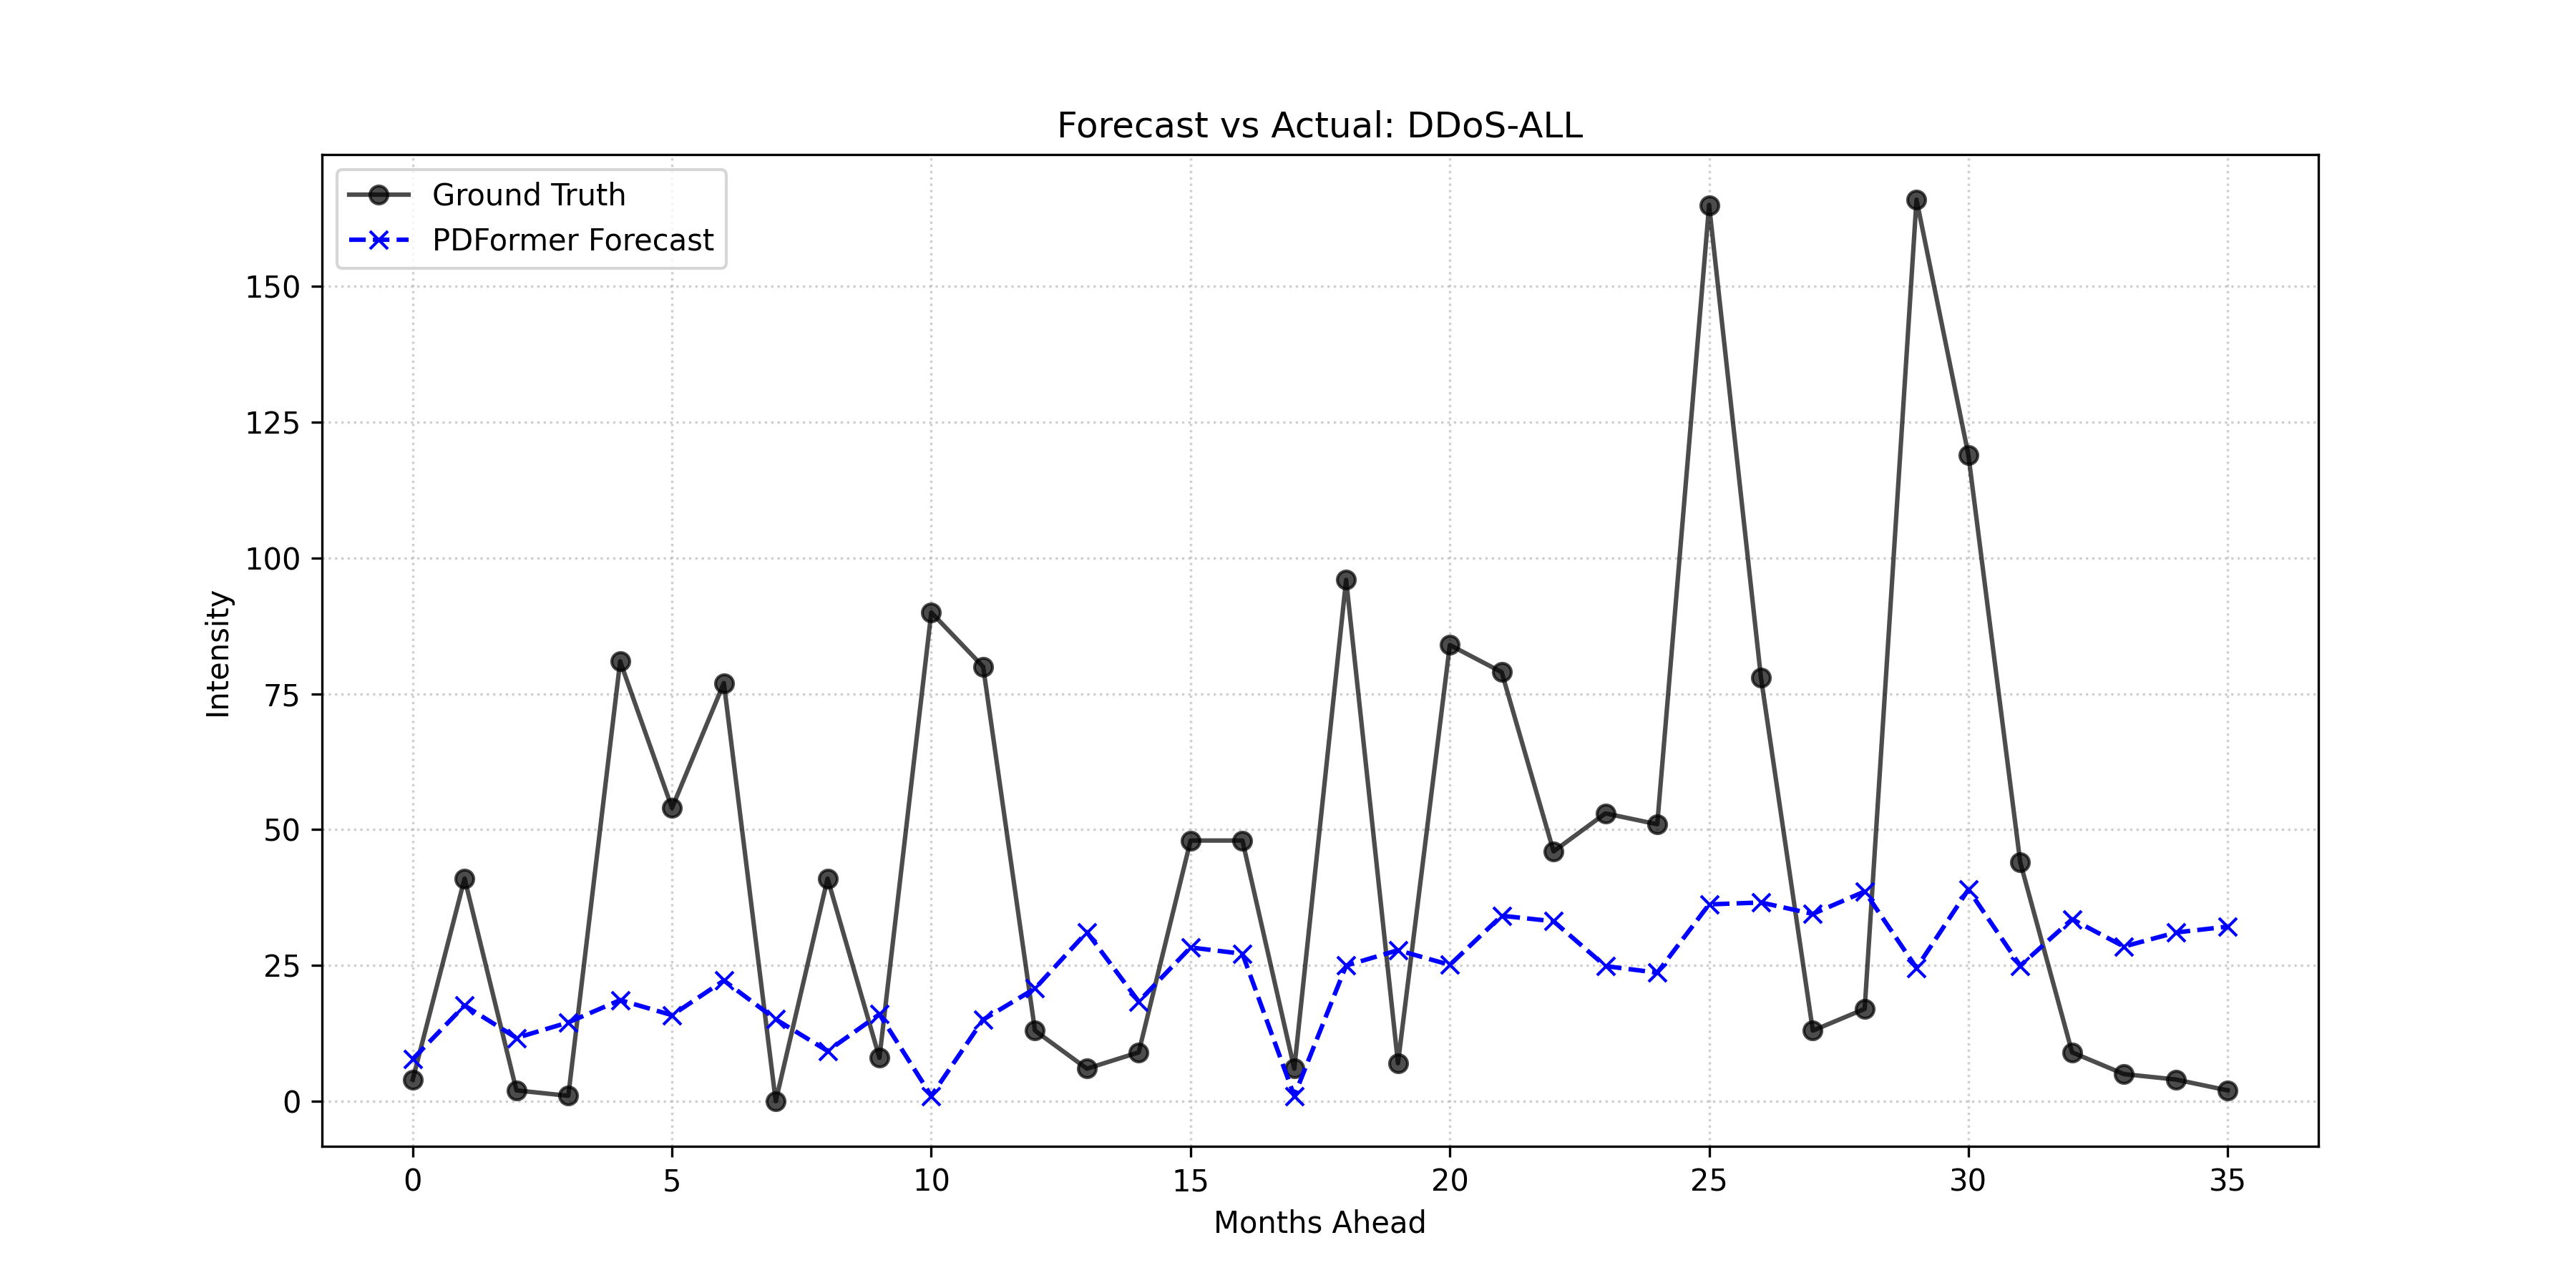

<Figure size 640x480 with 0 Axes>

In [2]:
print("--- Step 3: Generating Visualisations ---")

# 1. Run the visualisation script to create PNGs
%run Visualise_Results.py

# 2. Display the images inline
import os
from IPython.display import Image, display

results_dir = 'Results'
gap_plot = os.path.join(results_dir, 'gap_analysis.png')
forecast_plot = os.path.join(results_dir, 'forecast_vs_actual.png')

print("\n--- GAP ANALYSIS: Threat vs Mitigation ---")
if os.path.exists(gap_plot):
    display(Image(filename=gap_plot))
else:
    print("Gap analysis plot not found.")

print("\n--- FORECAST ACCURACY: Ground Truth vs Prediction ---")
if os.path.exists(forecast_plot):
    display(Image(filename=forecast_plot))
else:
    print("Forecast plot not found.")